In [ ]:
# load
from mapreader import loader
from mapreader import Annotator
from mapreader import AnnotationsLoader
from mapreader import ClassifierContainer
from mapreader import load_patches, PatchDataset
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
maps = loader("./maps_south_downs_1949_1972/*png")

In [5]:
maps.add_metadata("./maps_south_downs_1949_1972/metadata.csv", ignore_mismatch=True)

[INFO] Loading metadata from CSV/TSV/etc file.


In [9]:
maps.patchify_all(method="meters", patch_size=50)

[INFO] Saving patches in directory named "patches_50_meters".


  0%|          | 0/106 [00:00<?, ?it/s]

maps_south_downs_1949_1972/map_189245184.png
maps_south_downs_1949_1972/map_189245844.png
maps_south_downs_1949_1972/map_189258152.png
maps_south_downs_1949_1972/map_189258179.png
maps_south_downs_1949_1972/map_189244827.png
maps_south_downs_1949_1972/map_189259340.png
maps_south_downs_1949_1972/map_189258920.png
maps_south_downs_1949_1972/map_189245148.png
maps_south_downs_1949_1972/map_189246216.png
maps_south_downs_1949_1972/map_189258566.png
maps_south_downs_1949_1972/map_189259316.png
maps_south_downs_1949_1972/map_189259781.png
maps_south_downs_1949_1972/map_189245166.png
maps_south_downs_1949_1972/map_189262559.png
maps_south_downs_1949_1972/map_189245493.png
maps_south_downs_1949_1972/map_189245883.png
maps_south_downs_1949_1972/map_189259349.png
maps_south_downs_1949_1972/map_189244878.png
maps_south_downs_1949_1972/map_189259364.png
maps_south_downs_1949_1972/map_189244809.png
maps_south_downs_1949_1972/map_189245541.png
maps_south_downs_1949_1972/map_189245547.png
maps_south

In [3]:
# EXAMPLE
annotator = Annotator(
    patch_paths="./patches_50_meters/*.png",
    parent_paths="./maps_south_downs_1949_1972/*png",
    metadata_path="./maps_south_downs_1949_1972/metadata.csv", # or .geojson
    annotations_dir="./annotations",
    task_name="boundary",
    labels=["no_boundary", "boundary"],
    username="DA",
    show_context=True,
)

[INFO] Loading patches from ./patches_50_meters/*.png.
[INFO] Loading parents from ./maps_south_downs_1949_1972/*png.


0it [00:00, ?it/s]

  0%|          | 0/106 [00:00<?, ?it/s]

  0%|          | 0/1297074 [00:00<?, ?it/s]

  0%|          | 0/106 [00:00<?, ?it/s]

[INFO] Loading metadata from CSV/TSV/etc file.
[INFO] Adding metadata from ./maps_south_downs_1949_1972/metadata.csv.
[INFO] Loading existing patch annotations.


In [4]:
annotator.annotate()

Output(layout=Layout(align_items='center', display='flex', flex_flow='column'))

In [7]:
annotated_images = AnnotationsLoader()
annotated_images.load("./annotations/boundary_#DA#-c441ef809476a4fedfbd159ab71ac93a.csv")

[INFO] Reading "./annotations/boundary_#DA#-c441ef809476a4fedfbd159ab71ac93a.csv"
[INFO] Number of annotations:   1004

[INFO] Number of instances of each label (from column "label"):
    - no_boundary:  578
    - boundary:  426



In [8]:
annotated_images.create_datasets(frac_train=0.7, frac_val=0.2, frac_test=0.1)

[INFO] Number of annotations in each set:
    - train:   702
    - val:   201
    - test:   101


In [9]:
annotated_images.datasets["train"].patch_df.head()

,label,image_path,parent_id,pixel_bounds,label_index
image_id,,,,,
patch-2376-330-2409-363-#map_189259328.png#.png,no_boundary,./patches_50_meters/patch-2376-330-2409-363-#m...,map_189259328.png,"(2376, 330, 2409, 363)",0
patch-858-1320-891-1353-#map_189245160.png#.png,boundary,./patches_50_meters/patch-858-1320-891-1353-#m...,map_189245160.png,"(858, 1320, 891, 1353)",1
patch-561-66-594-99-#map_189259802.png#.png,no_boundary,./patches_50_meters/patch-561-66-594-99-#map_1...,map_189259802.png,"(561, 66, 594, 99)",0
patch-2838-3234-2871-3267-#map_189245136.png#.png,no_boundary,./patches_50_meters/patch-2838-3234-2871-3267-...,map_189245136.png,"(2838, 3234, 2871, 3267)",0
patch-3333-3366-3366-3399-#map_189245148.png#.png,boundary,./patches_50_meters/patch-3333-3366-3366-3399-...,map_189245148.png,"(3333, 3366, 3366, 3399)",1


In [10]:
dataloaders = annotated_images.create_dataloaders(batch_size=8)

[INFO] Using default sampler.


In [12]:
my_classifier = ClassifierContainer(
    model="resnet18", labels_map={0: "no_boundary", 1: "boundary"}, dataloaders=dataloaders
)

[INFO] Device is set to cuda:0
[INFO] Initializing model.
[INFO] Loaded "train" with 702 items.
[INFO] Loaded "val" with 201 items.
[INFO] Loaded "test" with 101 items.


In [13]:
my_classifier.labels_map

{0: 'no_boundary', 1: 'boundary'}

In [15]:
my_classifier.model_summary()

Layer (type:depth-idx)                   Output Shape              Output Shape              Param #
ResNet                                   [8, 2]                    [8, 2]                    --
├─Conv2d: 1-1                            [8, 64, 112, 112]         [8, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [8, 64, 112, 112]         [8, 64, 112, 112]         128
├─ReLU: 1-3                              [8, 64, 112, 112]         [8, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [8, 64, 56, 56]           [8, 64, 56, 56]           --
├─Sequential: 1-5                        [8, 64, 56, 56]           [8, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [8, 64, 56, 56]           [8, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [8, 64, 56, 56]           [8, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [8, 64, 56, 56]           [8, 64, 56, 56]           128
│    │    └─ReLU: 3-3     

In [19]:
import torch.nn as nn
my_classifier.add_loss_fn(nn.CrossEntropyLoss())

In [21]:
params_to_optimize = my_classifier.generate_layerwise_lrs(
    min_lr=1e-4, max_lr=1e-3, spacing="geomspace"
)

In [22]:
my_classifier.initialize_optimizer(params2optimize=params_to_optimize)

In [23]:
my_classifier.initialize_scheduler()

## Train

In [24]:
my_classifier.train(
    num_epochs=10,
    save_model_dir="./models",
    tensorboard_path="tboard",
    tmp_file_save_freq=2,
    remove_after_load=False,
    print_info_batch_freq=10,
)

[INFO] Each step will pass: ['train', 'val'].
2025-04-21 16:22:01 david-LEGI [INFO] train    -- 1/10 --      8/702 (  1.1% ) -- Loss: 0.630
2025-04-21 16:22:02 david-LEGI [INFO] train    -- 1/10 --     88/702 ( 12.5% ) -- Loss: 1.178
2025-04-21 16:22:02 david-LEGI [INFO] train    -- 1/10 --    168/702 ( 23.9% ) -- Loss: 1.008
2025-04-21 16:22:02 david-LEGI [INFO] train    -- 1/10 --    248/702 ( 35.3% ) -- Loss: 0.740
2025-04-21 16:22:02 david-LEGI [INFO] train    -- 1/10 --    328/702 ( 46.7% ) -- Loss: 0.989
2025-04-21 16:22:02 david-LEGI [INFO] train    -- 1/10 --    408/702 ( 58.1% ) -- Loss: 0.461
2025-04-21 16:22:03 david-LEGI [INFO] train    -- 1/10 --    488/702 ( 69.5% ) -- Loss: 0.543
2025-04-21 16:22:03 david-LEGI [INFO] train    -- 1/10 --    568/702 ( 80.9% ) -- Loss: 0.680
2025-04-21 16:22:03 david-LEGI [INFO] train    -- 1/10 --    648/702 ( 92.3% ) -- Loss: 0.525
2025-04-21 16:22:03 david-LEGI [INFO] train    -- 1/10 -- Loss: 0.735; F_macro: 0.64; R_macro: 0.64
2025-04-

In [26]:
list(my_classifier.metrics.keys())

['train', 'val']

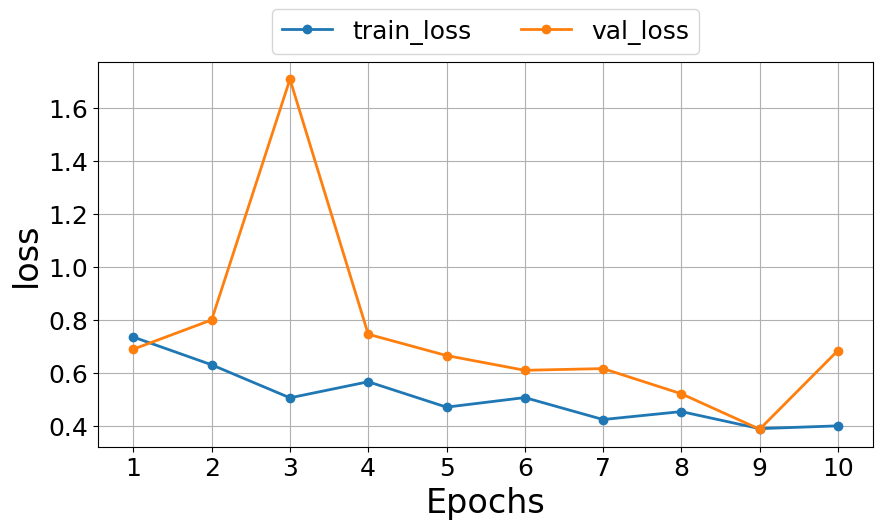

In [33]:
my_classifier.plot_metric(
    metrics=["loss"],        
    phases=["train", "val"],       
    figsize=(10, 5)               
)


In [32]:
list(my_classifier.metrics["train"].keys())

['loss',
 'precision_0',
 'recall_0',
 'fscore_0',
 'support_0',
 'precision_1',
 'recall_1',
 'fscore_1',
 'support_1',
 'precision_micro',
 'recall_micro',
 'fscore_micro',
 'support_micro',
 'rocauc_micro',
 'precision_macro',
 'recall_macro',
 'fscore_macro',
 'support_macro',
 'rocauc_macro',
 'precision_weighted',
 'recall_weighted',
 'fscore_weighted',
 'support_weighted',
 'rocauc_weighted']

In [35]:
my_classifier.inference("test")

[INFO] Each step will pass: ['test'].
2025-04-21 16:30:19 david-LEGI [INFO] test     -- 11/11 --      8/101 (  7.9% ) -- 
2025-04-21 16:30:19 david-LEGI [INFO] test     -- 11/11 --     48/101 ( 47.5% ) -- 
2025-04-21 16:30:19 david-LEGI [INFO] test     -- 11/11 --     88/101 ( 87.1% ) -- 
[INFO] Total time: 0m 0s


In [37]:
my_classifier.save("classifier.pkl")

## Inf

In [39]:
my_maps = load_patches(
    "./patches_50_meters/*.png",
    parent_paths="./maps_south_downs_1949_1972/*.png"
)

0it [00:00, ?it/s]

  0%|          | 0/106 [00:00<?, ?it/s]

  0%|          | 0/1297074 [00:00<?, ?it/s]

In [40]:
# Add map-level metadata
my_maps.add_metadata("./maps_south_downs_1949_1972/metadata.csv", ignore_mismatch=True)

[INFO] Loading metadata from CSV/TSV/etc file.


In [41]:
parent_df, patch_df = my_maps.convert_images()

In [42]:
patch_dataset = PatchDataset(patch_df, transform="val")

In [43]:
my_classifier.load_dataset(
    patch_dataset,
    set_name="patches",
    batch_size=8,
    shuffle=False  # Important: don’t shuffle during inference!
)

In [44]:
my_classifier.print_batch_info(set_name="patches")

[INFO] dataset: patches
        - items:        1297074
        - batch size:   8
        - batches:      162135


In [45]:
my_classifier.inference(set_name="patches")

[INFO] Each step will pass: ['patches'].
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 --  8/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 -- 48/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 -- 88/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 -- 128/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 -- 168/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 -- 208/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 -- 248/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 -- 288/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 -- 328/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 -- 368/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-LEGI [INFO] patches  -- 11/11 -- 408/1297074 (  0.0% ) -- 
2025-04-21 16:38:51 david-L

In [48]:
predictions_df = patch_dataset.patch_df

In [49]:
import numpy as np
import pandas as pd

predictions_df["predicted_label"] = my_classifier.pred_label
predictions_df["pred"] = my_classifier.pred_label_indices
predictions_df["conf"] = np.array(my_classifier.pred_conf).max(axis=1)

predictions_df.head()

,parent_id,image_path,pixel_bounds,coordinates,crs,geometry,predicted_label,pred,conf
image_id,,,,,,,,,
patch-2508-2574-2541-2607-#map_189258500.png#.png,map_189258500.png,./patches_50_meters/patch-2508-2574-2541-2607-...,"(2508, 2574, 2541, 2607)","(-0.3856372833251953, 50.846929866687475, -0.3...",EPSG:4326,"POLYGON ((-0.38493 50.84693, -0.38493 50.84738...",no_boundary,0,0.953270
patch-1848-660-1881-693-#map_189245502.png#.png,map_189245502.png,./patches_50_meters/patch-1848-660-1881-693-#m...,"(1848, 660, 1881, 693)","(-0.8941841125488281, 51.05621496760099, -0.89...",EPSG:4326,"POLYGON ((-0.89348 51.05621, -0.89348 51.05666...",boundary,1,0.863165
patch-2442-1551-2475-1584-#map_189244866.png#.png,map_189244866.png,./patches_50_meters/patch-2442-1551-2475-1584-...,"(2442, 1551, 2475, 1584)","(-1.2384939193725586, 51.092519956970385, -1.2...",EPSG:4326,"POLYGON ((-1.23779 51.09252, -1.23779 51.09296...",boundary,1,0.797591
patch-1518-2442-1551-2475-#map_189246234.png#.png,map_189246234.png,./patches_50_meters/patch-1518-2442-1551-2475-...,"(1518, 2442, 1551, 2475)","(-0.6211137771606445, 50.89378419192631, -0.62...",EPSG:4326,"POLYGON ((-0.62041 50.89378, -0.62041 50.89423...",no_boundary,0,0.945481
patch-0-1485-33-1518-#map_189245487.png#.png,map_189245487.png,./patches_50_meters/patch-0-1485-33-1518-#map_...,"(0, 1485, 33, 1518)","(-0.9393310546875, 50.91019804679459, -0.93862...",EPSG:4326,"POLYGON ((-0.93862 50.91020, -0.93862 50.91064...",no_boundary,0,0.949296


In [51]:
patch_dataset = PatchDataset(patch_df, transform="val")
my_classifier.load_dataset(patch_dataset, set_name="patches", batch_size=8, shuffle=False)


In [52]:
my_maps.add_shape()

[INFO] Add shape, tree level: parent


In [67]:
parent_df, patch_df = my_maps.convert_images()
parent_df.head(1)

,parent_id,image_path,patches,name,url,coordinates,crs,published_date,grid_bb,geometry,shape,dlon,dlat
image_id,,,,,,,,,,,,,
map_189245184.png,None,/home/david/Documents/GitHub/field-boundaries/...,[patch-3135-792-3168-825-#map_189245184.png#.p...,map_189245184.png,https://maps.nls.uk/view/189245184,"(-1.07666015625, 51.10697105503077, -0.9997558...",EPSG:4326,1961,"[(16, 32572, 21894)x(16, 32585, 21908)]","POLYGON ((-0.99976 51.10697, -0.99976 51.15868...","(3840, 3584, 4)",0.000021,0.000013


In [60]:
# Check the columns
print(patch_df.columns.tolist())


['parent_id', 'image_path', 'pixel_bounds', 'coordinates', 'crs', 'geometry', 'predicted_label', 'pred', 'conf', 'image_id']


In [ ]:
patch_df = patch_df.drop(columns=["pred", "predicted_label", "conf"], errors="ignore")

patch_df = patch_df.merge(
    predictions_df[["pred", "predicted_label", "conf"]],
    left_index=True,
    right_index=True,
    how="left"
)

patch_dict = patch_df.to_dict(orient="index")
my_maps.patches = patch_dict  

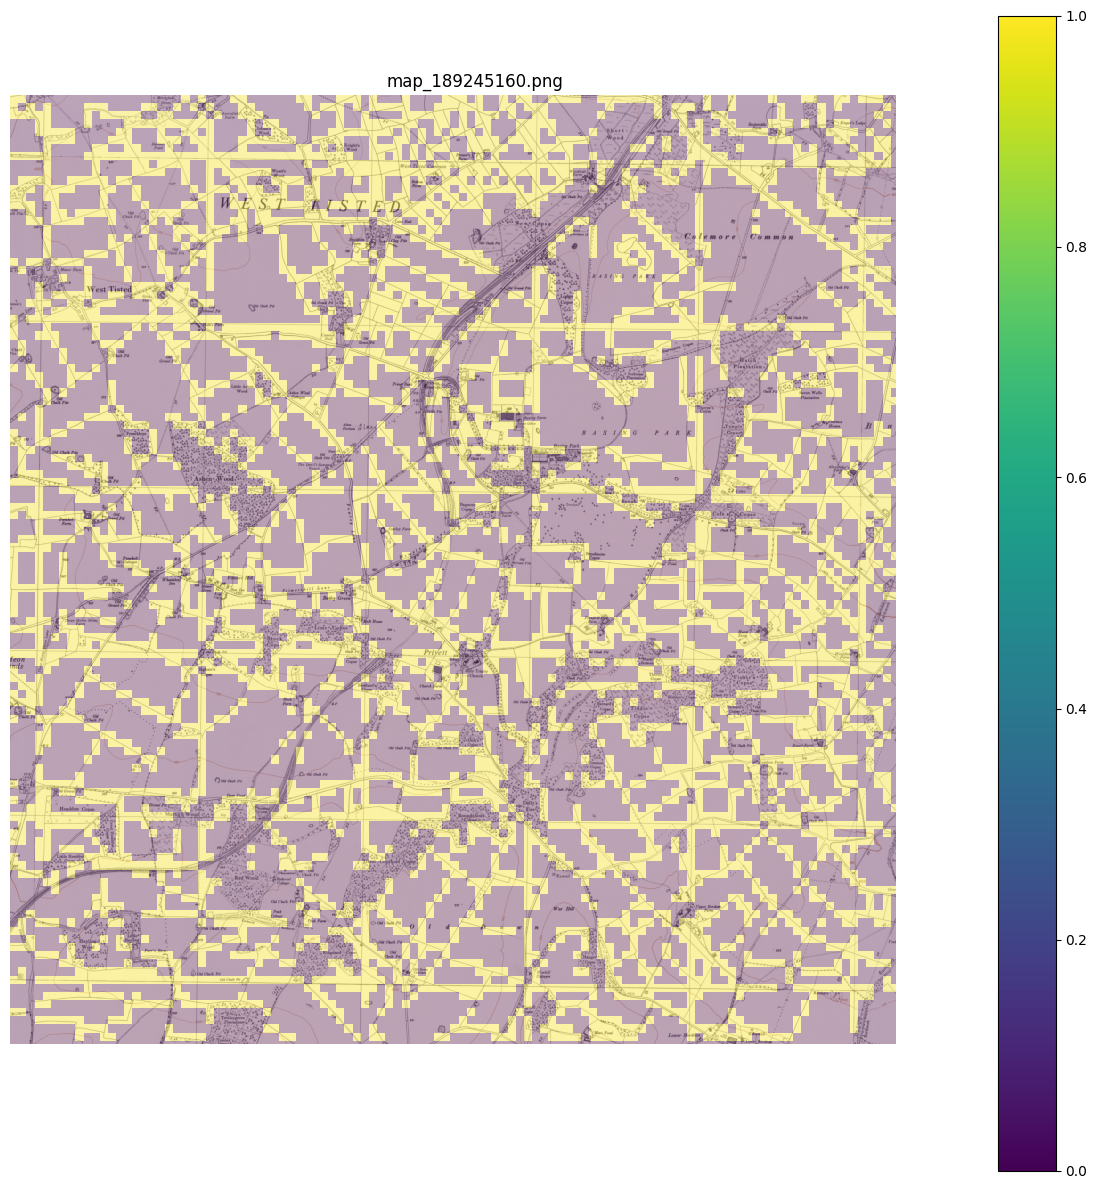

In [108]:
my_maps.show_patches(
    parent_id="map_189245160.png",  
    column_to_plot="pred",
    figsize=(15, 15),
    alpha=0.35
)
